#A comaparison study on Social Media Addiction

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import seaborn as sns
import matplotlib.pyplot as plt

SMA_Data = pd.read_csv("/content/drive/MyDrive/Research/Mukhles and Biplob code/SMA.csv")

In [3]:
#SMA_Data = pd.read_csv('"/content/drive/MyDrive/Research/Mukhles and Biplob code/SMA_description.txt',sep = "-")
#SMA_Data = SMA_Data.reset_index()
#SMA_Data.columns = ['cols','abb_col_names']

In [4]:
SMA_Data

,Q1_Gender,Q2_Living_Area,Q3_Maritial_Status,SMA1,SMA2,SMA3,SMA4,SMA5,SMA6,SMA7,SMA8,SMA9,SMA10,Scale_value,Add_lebel
0,1,1,2,4,5,1,3,5,2,2,4,5,3,31,2
1,1,1,2,3,2,1,5,5,1,1,2,5,1,25,2
2,2,1,2,3,2,1,1,1,1,1,1,1,1,12,1
3,1,2,2,2,5,5,2,3,1,3,4,4,1,29,2
4,1,1,2,1,4,3,1,2,1,1,1,1,1,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024,2,1,2,5,3,1,2,4,1,1,3,3,1,23,2
1025,1,1,2,5,5,4,3,3,1,3,4,2,3,30,2
1026,2,1,2,5,5,4,1,4,2,4,1,5,1,31,2
1027,1,2,2,2,3,1,2,1,1,1,2,4,1,17,1


In [5]:
SMA_Data.Add_lebel.value_counts()

,count
Add_lebel,
2,728
1,259
3,42


In [6]:
SMA_Data_raw = SMA_Data.drop(['Q1_Gender','Q2_Living_Area','Q3_Maritial_Status','Scale_value'], axis = 1)

In [7]:
from sklearn.impute import SimpleImputer
# stategy = 'median','mean','most_frequent'
impute = SimpleImputer(strategy = 'mean')
data_array = impute.fit_transform(SMA_Data_raw)

In [8]:
SMA_Data_df = pd.DataFrame(data_array, columns = SMA_Data_raw.columns)

In [9]:
SMA_Data_df

,SMA1,SMA2,SMA3,SMA4,SMA5,SMA6,SMA7,SMA8,SMA9,SMA10,Add_lebel
0,4.0,5.0,1.0,3.0,5.0,2.0,2.0,4.0,5.0,3.0,2.0
1,3.0,2.0,1.0,5.0,5.0,1.0,1.0,2.0,5.0,1.0,2.0
2,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,2.0,5.0,5.0,2.0,3.0,1.0,3.0,4.0,4.0,1.0,2.0
4,1.0,4.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1024,5.0,3.0,1.0,2.0,4.0,1.0,1.0,3.0,3.0,1.0,2.0
1025,5.0,5.0,4.0,3.0,3.0,1.0,3.0,4.0,2.0,3.0,2.0
1026,5.0,5.0,4.0,1.0,4.0,2.0,4.0,1.0,5.0,1.0,2.0
1027,2.0,3.0,1.0,2.0,1.0,1.0,1.0,2.0,4.0,1.0,1.0


In [10]:
SMA_Data_raw

,SMA1,SMA2,SMA3,SMA4,SMA5,SMA6,SMA7,SMA8,SMA9,SMA10,Add_lebel
0,4,5,1,3,5,2,2,4,5,3,2
1,3,2,1,5,5,1,1,2,5,1,2
2,3,2,1,1,1,1,1,1,1,1,1
3,2,5,5,2,3,1,3,4,4,1,2
4,1,4,3,1,2,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
1024,5,3,1,2,4,1,1,3,3,1,2
1025,5,5,4,3,3,1,3,4,2,3,2
1026,5,5,4,1,4,2,4,1,5,1,2
1027,2,3,1,2,1,1,1,2,4,1,1


In [11]:
X = SMA_Data_raw.drop('Add_lebel', axis = 1)
Y = SMA_Data_raw['Add_lebel']

In [12]:
X

,SMA1,SMA2,SMA3,SMA4,SMA5,SMA6,SMA7,SMA8,SMA9,SMA10
0,4,5,1,3,5,2,2,4,5,3
1,3,2,1,5,5,1,1,2,5,1
2,3,2,1,1,1,1,1,1,1,1
3,2,5,5,2,3,1,3,4,4,1
4,1,4,3,1,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1024,5,3,1,2,4,1,1,3,3,1
1025,5,5,4,3,3,1,3,4,2,3
1026,5,5,4,1,4,2,4,1,5,1
1027,2,3,1,2,1,1,1,2,4,1


In [13]:
Y

,Add_lebel
0,2
1,2
2,1
3,2
4,1
...,...
1024,2
1025,2
1026,2
1027,1


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
# Dense Neural Network
from tensorflow.keras.layers import Dense, Dropout
# Sequential Connection with Neural Network
from tensorflow.keras.models import Sequential
# Optimizers for Regression Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, PReLU

#from tensorflow.keras.layers import PReLU, ELU, Activation
#from tensorflow.keras.layers import Dense, LeakyReLU
from keras.layers import Dense, Activation, LeakyReLU, PReLU, ELU

In [15]:
!pip install tensorflow
from tensorflow.keras.utils import to_categorical

##All Machine Learning outputs

In [16]:
# Assume 'target' is the column you want to predict
X = X
y = Y

# Encode labels if they are not numerical
le = LabelEncoder()
y = le.fit_transform(y)

# Split the dataset into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Define models to be evaluated
models = {
    'Logistic Regression': LogisticRegression(),
    'Support Vector Machines': SVC(),
    'Linear SVC': LinearSVC(),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Perceptron': Perceptron(),
    'Stochastic Gradient Descent': SGDClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBClassifier': XGBClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
}

# Initialize an empty list to store the results
results_list = []

# Training and evaluating the models
for model_name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)

    # Training set
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    train_recall = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    # Testing set
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Validation set
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    # Store results in the list
    results_list.append({
        'Model': model_name,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Validation Accuracy': val_accuracy,
        'CPU times': time.time() - start_time,
        'MSE': val_mse,  # Use validation MSE as the overall MSE
        'Precision': train_precision,
        'Recall': train_recall,
        'F1 Score': train_f1
    })

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results_list)

# Display the results
results_df


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

,Model,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU times,MSE,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,0.987013,0.993548,0.072525,0.006452,1.000000,1.000000,1.000000
1,Support Vector Machines,0.997222,0.974026,0.993548,0.040142,0.006452,0.997233,0.997222,0.997211
2,Linear SVC,0.937500,0.922078,0.948387,0.028665,0.051613,0.902272,0.937500,0.918157
3,k-Nearest Neighbors,0.961111,0.935065,0.922581,0.088489,0.077419,0.962419,0.961111,0.961451
4,Naive Bayes,0.905556,0.863636,0.864516,0.026195,0.135484,0.924796,0.905556,0.910031
5,Perceptron,0.936111,0.909091,0.935484,0.027653,0.064516,0.898479,0.936111,0.916861
6,Stochastic Gradient Descent,0.976389,0.967532,0.974194,0.029954,0.025806,0.976822,0.976389,0.973914
7,Decision Tree Classifier,1.000000,0.909091,0.896774,0.041036,0.103226,1.000000,1.000000,1.000000
8,Random Forest,1.000000,0.928571,0.948387,0.417654,0.051613,1.000000,1.000000,1.000000
9,XGBClassifier,1.000000,0.935065,0.967742,0.225065,0.032258,1.000000,1.000000,1.000000


Logistic Regression Accuracy: 0.928571
Logistic Regression F1-Score: 0.910079


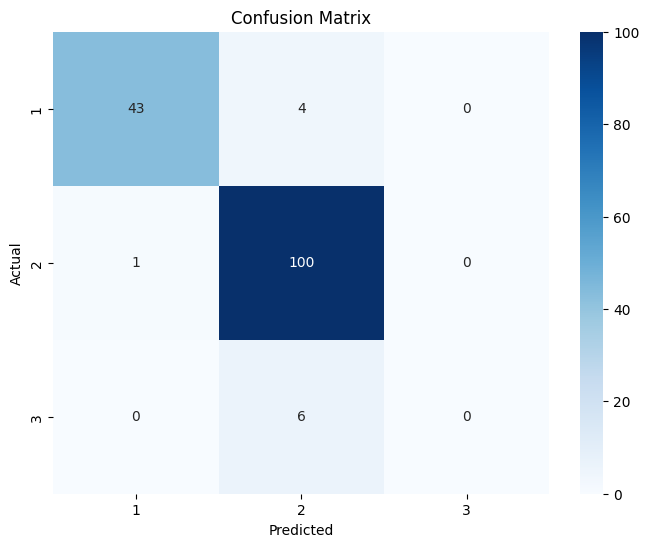

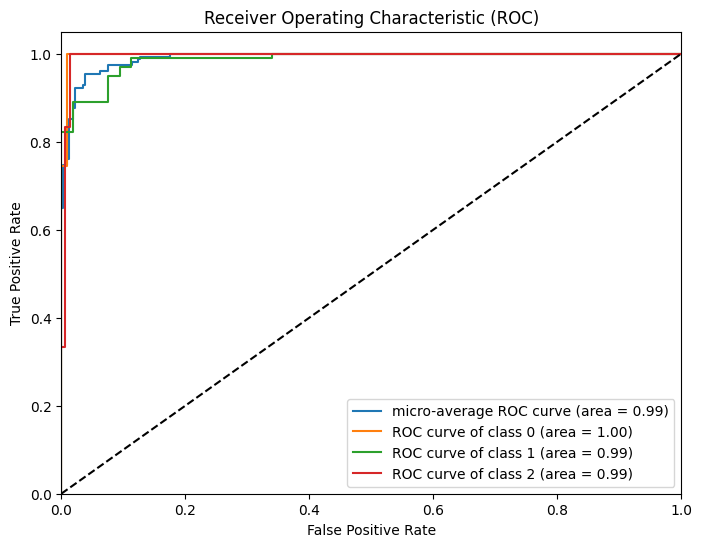

   Accuracy  F1-Score
0  0.928571  0.910079


In [17]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Assume 'X' is the feature matrix and 'y' is the target
X = X  # Feature matrix
y = Y  # Target labels

# Encode labels if they are not numerical
le = LabelEncoder()
y = le.fit_transform(y)

# Split the dataset into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize the features to avoid convergence warning in Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Logistic Regression model with OneVsRestClassifier for multiclass handling
model = OneVsRestClassifier(LogisticRegression(max_iter=300, C=0.5, solver='liblinear'))

# Train the model
start_time = time.time()
model.fit(X_train_scaled, y_train)

# Predict on the testing set
y_test_pred = model.predict(X_test_scaled)

# Calculate Accuracy and F1-Score
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred, average='weighted')  # Weighted average for multi-class
print(f"Logistic Regression Accuracy: {accuracy:.6f}")
print(f"Logistic Regression F1-Score: {f1:.6f}")

# Prepare results for DataFrame
results = {
    'Accuracy': [accuracy],
    'F1-Score': [f1]
}
results_df = pd.DataFrame(results)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate ROC Curve and AUC for each class
y_test_prob = model.predict_proba(X_test_scaled)
fpr = {}
tpr = {}
roc_auc = {}
num_classes = len(np.unique(y))  # Number of classes in the target

# For each class, calculate ROC curve and AUC
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarize(y_test, classes=[0, 1, 2])[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarize(y_test, classes=[0, 1, 2]).ravel(), y_test_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"], label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})')

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {i} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print results dataframe
print(results_df)


In [18]:
# Calculate ROC Curve and AUC for each class
y_test_prob = model.predict_proba(X_test_scaled)
fpr = {}
tpr = {}
roc_auc = {}
num_classes = len(np.unique(y))  # Number of classes in the target

# For each class, calculate ROC curve and AUC
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(label_binarize(y_test, classes=[0, 1, 2])[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(label_binarize(y_test, classes=[0, 1, 2]).ravel(), y_test_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

##Model 1 (21,20) Custom FB_ANN. activation= 'relu' + 'softmax' + loss='categorical_crossentropy' | Optimizer= Adam | 4th hidden layer

In [19]:
# Assume 'target' is the column you want to predict
X = X
Y = Y

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training, validation, and testing sets
X_train, X_interim, y_train, y_interim = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42)

# One-hot encode the target variables

y_train = to_categorical(y_train)
y_validation = to_categorical(y_validation)
y_test = to_categorical(y_test)

# Print shapes of the datasets
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Define the combinations of neurons and epochs
combinations = [
    {'neurons': (6, 5, 12, 13), 'epochs': 68},
    {'neurons': (12, 13, 15, 12), 'epochs': 66},
    {'neurons': (5, 14, 14, 5), 'epochs': 31},
    {'neurons': (8, 12, 14, 13), 'epochs': 66},
    {'neurons': (12, 13, 11, 10), 'epochs': 34},
    {'neurons': (15, 10, 9, 7), 'epochs': 47},
    {'neurons': (10, 14, 8, 13), 'epochs': 69},
    {'neurons': (7, 5, 5, 14), 'epochs': 43},
    {'neurons': (10, 12, 7, 14), 'epochs': 49},
    {'neurons': (8, 5, 9, 15), 'epochs': 28},
    {'neurons': (13, 8, 7, 12), 'epochs': 7},
    {'neurons': (9, 6, 10, 10), 'epochs': 30},
]

results = []

for combination in combinations:
    start_time = time.time()


    # Determine the number of unique classes
    num_classes = y_train.shape[1]  # Assuming y_train is one-hot encoded

    # Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
    model = Sequential()
    model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
    model.add(Activation('relu'))
    model.add(Dense(combination['neurons'][1]))
    model.add(Activation('relu'))
    model.add(Dense(combination['neurons'][2]))
    model.add(Activation('relu'))
    model.add(Dense(combination['neurons'][3]))
    model.add(Activation('relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Softmax activation for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Use categorical_crossentropy for one-hot encoded targets

    # Print model summary
    model.summary()

    # Train the model
    model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

    # Calculate metrics
    train_preds = model.predict(X_train).argmax(axis=1)
    test_preds = model.predict(X_test).argmax(axis=1)
    val_preds = model.predict(X_validation).argmax(axis=1)

    # Convert one-hot encoded y_train back to single labels for metric calculation
    y_train_labels = y_train.argmax(axis=1)
    y_test_labels = y_test.argmax(axis=1)
    y_val_labels = y_validation.argmax(axis=1)

    accuracy_train = accuracy_score(y_train_labels, train_preds) # Use single label version of y_train
    accuracy_test = accuracy_score(y_test_labels, test_preds)
    accuracy_validation = accuracy_score(y_val_labels, val_preds)

    mse = mean_squared_error(y_test_labels, test_preds)
    precision = precision_score(y_test_labels, test_preds, average='weighted')
    recall = recall_score(y_test_labels, test_preds, average='weighted')
    f1 = f1_score(y_test_labels, test_preds, average='weighted')


    results.append({
        'Combination of Neurons': combination['neurons'],
        'Epochs': combination['epochs'],
        'Training Accuracy': accuracy_train,
        'Testing Accuracy': accuracy_test,
        'Validation Accuracy': accuracy_validation,
        'CPU times': time.time() - start_time,
        'MSE': mse,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
results_df

Shapes:
X_train: (720, 10) y_train: (720, 4)
X_validation: (154, 10) y_validation: (154, 4)
X_test: (155, 10) y_test: (155, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 13)                  │             169 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │              56 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 398 (1.55 KB)

...

 Trainable params: 383 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Combination of Neurons,Epochs,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU times,MSE,Precision,Recall,F1 Score
0,"(6, 5, 12, 13)",68,0.991667,0.980645,0.974026,26.967788,0.019355,0.980778,0.980645,0.980651
1,"(12, 13, 15, 12)",66,0.998611,0.980645,0.928571,12.792265,0.019355,0.981137,0.980645,0.979645
2,"(5, 14, 14, 5)",31,0.963889,0.967742,0.948052,6.967837,0.032258,0.967291,0.967742,0.967117
3,"(8, 12, 14, 13)",66,0.997222,0.980645,0.961039,10.806516,0.019355,0.980756,0.980645,0.980637
4,"(12, 13, 11, 10)",34,0.991667,0.987097,0.980519,6.422352,0.012903,0.987097,0.987097,0.987097
5,"(15, 10, 9, 7)",47,0.994444,0.980645,0.967532,8.494204,0.019355,0.981137,0.980645,0.978130
6,"(10, 14, 8, 13)",69,0.994444,0.967742,0.961039,10.639322,0.032258,0.965758,0.967742,0.966571
7,"(7, 5, 5, 14)",43,0.954167,0.954839,0.941558,7.772699,0.045161,0.912269,0.954839,0.932925
8,"(10, 12, 7, 14)",49,0.983333,0.980645,0.961039,8.370350,0.019355,0.980756,0.980645,0.980439
9,"(8, 5, 9, 15)",28,0.944444,0.935484,0.928571,5.225909,0.064516,0.936640,0.935484,0.935438


##Model 2 (21,20) Custom FB_ANN. activation= LeakyReLU(alpha=0.01) + 'sigmoid' + loss='categorical_crossentropy' | Optimizer= Adam | 4th hidden layer

In [20]:
# Assume 'target' is the column you want to predict
X = X
Y = Y

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training, validation, and testing sets
X_train, X_interim, y_train, y_interim = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42)

# One-hot encode the target variables

y_train = to_categorical(y_train)
y_validation = to_categorical(y_validation)
y_test = to_categorical(y_test)

# Print shapes of the datasets
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Define the combinations of neurons and epochs
combinations = [
    {'neurons': (6, 5, 12, 13), 'epochs': 68},
    {'neurons': (12, 13, 15, 12), 'epochs': 66},
    {'neurons': (5, 14, 14, 5), 'epochs': 31},
    {'neurons': (8, 12, 14, 13), 'epochs': 66},
    {'neurons': (12, 13, 11, 10), 'epochs': 34},
    {'neurons': (15, 10, 9, 7), 'epochs': 47},
    {'neurons': (10, 14, 8, 13), 'epochs': 69},
    {'neurons': (7, 5, 5, 14), 'epochs': 43},
    {'neurons': (10, 12, 7, 14), 'epochs': 49},
    {'neurons': (8, 5, 9, 15), 'epochs': 28},
    {'neurons': (13, 8, 7, 12), 'epochs': 7},
    {'neurons': (9, 6, 10, 10), 'epochs': 30},
]

results = []

for combination in combinations:
    start_time = time.time()


    # Determine the number of unique classes
    num_classes = y_train.shape[1]  # Assuming y_train is one-hot encoded

    # Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
    model = Sequential()
    model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
    model.add(LeakyReLU(alpha=0.01))
    model.add(Dense(combination['neurons'][1]))
    model.add(LeakyReLU(alpha=0.01))
    model.add(Dense(combination['neurons'][2]))
    model.add(LeakyReLU(alpha=0.01))
    model.add(Dense(combination['neurons'][3]))
    model.add(LeakyReLU(alpha=0.01))
    model.add(Dense(num_classes, activation='sigmoid'))  # Softmax activation for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Use categorical_crossentropy for one-hot encoded targets

    # Print model summary
    model.summary()

    # Train the model
    model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

    # Calculate metrics
    train_preds = model.predict(X_train).argmax(axis=1)
    test_preds = model.predict(X_test).argmax(axis=1)
    val_preds = model.predict(X_validation).argmax(axis=1)

    # Convert one-hot encoded y_train back to single labels for metric calculation
    y_train_labels = y_train.argmax(axis=1)
    y_test_labels = y_test.argmax(axis=1)
    y_val_labels = y_validation.argmax(axis=1)

    accuracy_train = accuracy_score(y_train_labels, train_preds) # Use single label version of y_train
    accuracy_test = accuracy_score(y_test_labels, test_preds)
    accuracy_validation = accuracy_score(y_val_labels, val_preds)

    mse = mean_squared_error(y_test_labels, test_preds)
    precision = precision_score(y_test_labels, test_preds, average='weighted')
    recall = recall_score(y_test_labels, test_preds, average='weighted')
    f1 = f1_score(y_test_labels, test_preds, average='weighted')


    results.append({
        'Combination of Neurons': combination['neurons'],
        'Epochs': combination['epochs'],
        'Training Accuracy': accuracy_train,
        'Testing Accuracy': accuracy_test,
        'Validation Accuracy': accuracy_validation,
        'CPU times': time.time() - start_time,
        'MSE': mse,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
results_df


Shapes:
X_train: (720, 10) y_train: (720, 4)
X_validation: (154, 10) y_validation: (154, 4)
X_test: (155, 10) y_test: (155, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                     │ (None, 6)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 5)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 13)                  │             169 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 13)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 4)                   │              56 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 398 (1.55 KB)

...

 Total params: 383 (1.50 KB)

 Trainable params: 383 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Combination of Neurons,Epochs,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU times,MSE,Precision,Recall,F1 Score
0,"(6, 5, 12, 13)",68,0.986111,0.961290,0.974026,11.092977,0.038710,0.962903,0.961290,0.959072
1,"(12, 13, 15, 12)",66,0.998611,0.967742,0.967532,10.823588,0.032258,0.967291,0.967742,0.967117
2,"(5, 14, 14, 5)",31,0.936111,0.935484,0.922078,6.874861,0.064516,0.893261,0.935484,0.913868
3,"(8, 12, 14, 13)",66,1.000000,0.980645,0.948052,10.740270,0.019355,0.980946,0.980645,0.979660
4,"(12, 13, 11, 10)",34,0.956944,0.954839,0.941558,6.357100,0.045161,0.912269,0.954839,0.932925
5,"(15, 10, 9, 7)",47,0.983333,0.961290,0.967532,8.624479,0.038710,0.966096,0.961290,0.962750
6,"(10, 14, 8, 13)",69,0.980556,0.980645,0.954545,11.337975,0.019355,0.981137,0.980645,0.978130
7,"(7, 5, 5, 14)",43,0.981944,0.974194,0.948052,6.998219,0.025806,0.973308,0.974194,0.973497
8,"(10, 12, 7, 14)",49,0.997222,0.948387,0.948052,9.992103,0.051613,0.945351,0.948387,0.946698
9,"(8, 5, 9, 15)",28,0.934722,0.935484,0.915584,5.230482,0.064516,0.893261,0.935484,0.913868


##Model 3 (21,20) Custom FB_ANN. activation= PReLU()  + 'sigmoid' + loss='categorical_crossentropy' | Optimizer= Adam | 4th hidden layer

In [21]:
# Assume 'target' is the column you want to predict
X = X
Y = Y

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training, validation, and testing sets
X_train, X_interim, y_train, y_interim = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42)

# One-hot encode the target variables

y_train = to_categorical(y_train)
y_validation = to_categorical(y_validation)
y_test = to_categorical(y_test)

# Print shapes of the datasets
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Define the combinations of neurons and epochs
combinations = [
    {'neurons': (6, 5, 12, 13), 'epochs': 68},
    {'neurons': (12, 13, 15, 12), 'epochs': 66},
    {'neurons': (5, 14, 14, 5), 'epochs': 31},
    {'neurons': (8, 12, 14, 13), 'epochs': 66},
    {'neurons': (12, 13, 11, 10), 'epochs': 34},
    {'neurons': (15, 10, 9, 7), 'epochs': 47},
    {'neurons': (10, 14, 8, 13), 'epochs': 69},
    {'neurons': (7, 5, 5, 14), 'epochs': 43},
    {'neurons': (10, 12, 7, 14), 'epochs': 49},
    {'neurons': (8, 5, 9, 15), 'epochs': 28},
    {'neurons': (13, 8, 7, 12), 'epochs': 7},
    {'neurons': (9, 6, 10, 10), 'epochs': 30},
]

results = []

for combination in combinations:
    start_time = time.time()


    # Determine the number of unique classes
    num_classes = y_train.shape[1]  # Assuming y_train is one-hot encoded

    # Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
    model = Sequential()
    model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][1]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][2]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][3]))
    model.add(PReLU())
    model.add(Dense(num_classes, activation='sigmoid'))  # Softmax activation for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Use categorical_crossentropy for one-hot encoded targets

    # Print model summary
    model.summary()

    # Train the model
    model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

    # Calculate metrics
    train_preds = model.predict(X_train).argmax(axis=1)
    test_preds = model.predict(X_test).argmax(axis=1)
    val_preds = model.predict(X_validation).argmax(axis=1)

    # Convert one-hot encoded y_train back to single labels for metric calculation
    y_train_labels = y_train.argmax(axis=1)
    y_test_labels = y_test.argmax(axis=1)
    y_val_labels = y_validation.argmax(axis=1)

    accuracy_train = accuracy_score(y_train_labels, train_preds) # Use single label version of y_train
    accuracy_test = accuracy_score(y_test_labels, test_preds)
    accuracy_validation = accuracy_score(y_val_labels, val_preds)

    mse = mean_squared_error(y_test_labels, test_preds)
    precision = precision_score(y_test_labels, test_preds, average='weighted')
    recall = recall_score(y_test_labels, test_preds, average='weighted')
    f1 = f1_score(y_test_labels, test_preds, average='weighted')


    results.append({
        'Combination of Neurons': combination['neurons'],
        'Epochs': combination['epochs'],
        'Training Accuracy': accuracy_train,
        'Testing Accuracy': accuracy_test,
        'Validation Accuracy': accuracy_validation,
        'CPU times': time.time() - start_time,
        'MSE': mse,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
results_df

Shapes:
X_train: (720, 10) y_train: (720, 4)
X_validation: (154, 10) y_validation: (154, 4)
X_test: (155, 10) y_test: (155, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_120 (Dense)                    │ (None, 6)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu (PReLU)                      │ (None, 6)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_121 (Dense)                    │ (None, 5)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_1 (PReLU)                    │ (None, 5)                   │               5 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_122 (Dense)                    │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_2 (PReLU)                    │ (None, 12)                  │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_123 (Dense)                    │ (None, 13)                  │             169 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_3 (PReLU)                    │ (None, 13)                  │              13 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_124 (Dense)                    │ (None, 4)                   │              56 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 434 (1.70 KB)

...

 Total params: 418 (1.63 KB)

 Trainable params: 418 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


,Combination of Neurons,Epochs,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU times,MSE,Precision,Recall,F1 Score
0,"(6, 5, 12, 13)",68,0.993056,0.974194,0.967532,12.050573,0.025806,0.975882,0.974194,0.974774
1,"(12, 13, 15, 12)",66,0.995833,0.974194,0.987013,12.280027,0.025806,0.973308,0.974194,0.973497
2,"(5, 14, 14, 5)",31,0.973611,0.961290,0.922078,6.923517,0.038710,0.966096,0.961290,0.962750
3,"(8, 12, 14, 13)",66,0.997222,0.993548,0.980519,11.362994,0.006452,0.993604,0.993548,0.993314
4,"(12, 13, 11, 10)",34,0.984722,0.967742,0.961039,8.168141,0.032258,0.969919,0.967742,0.968364
5,"(15, 10, 9, 7)",47,0.983333,0.974194,0.941558,11.554379,0.025806,0.973449,0.974194,0.973511
6,"(10, 14, 8, 13)",69,0.998611,0.974194,0.980519,13.064126,0.025806,0.973308,0.974194,0.973497
7,"(7, 5, 5, 14)",43,0.986111,0.974194,0.974026,7.931736,0.025806,0.974194,0.974194,0.974194
8,"(10, 12, 7, 14)",49,0.991667,0.967742,0.954545,10.202897,0.032258,0.969182,0.967742,0.967950
9,"(8, 5, 9, 15)",28,0.972222,0.967742,0.941558,7.718707,0.032258,0.968588,0.967742,0.962836


##Confusion Matrix , ROC, AUC for maximum accurecy with minimum MSE based on combinations of neurons

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, mean_squared_error, precision_score, recall_score, f1_score
import seaborn as sns


Shapes:
X_train: (720, 10) y_train: (720, 4)
X_validation: (154, 10) y_validation: (154, 4)
X_test: (155, 10) y_test: (155, 4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_180 (Dense)                    │ (None, 8)                   │              88 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_48 (PReLU)                   │ (None, 8)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_181 (Dense)                    │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_49 (PReLU)                   │ (None, 5)                   │               5 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_182 (Dense)                    │ (None, 9)                   │              54 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_50 (PReLU)                   │ (None, 9)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_183 (Dense)                    │ (None, 15)                  │             150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_51 (PReLU)                   │ (None, 15)                  │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_184 (Dense)                    │ (None, 4)                   │              64 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 438 (1.71 KB)

 Trainable params: 438 (1.71 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


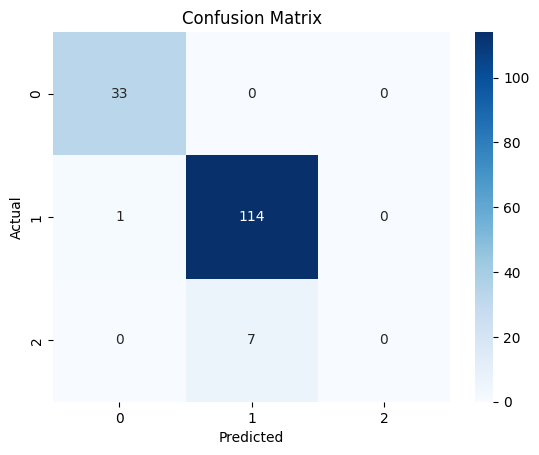

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


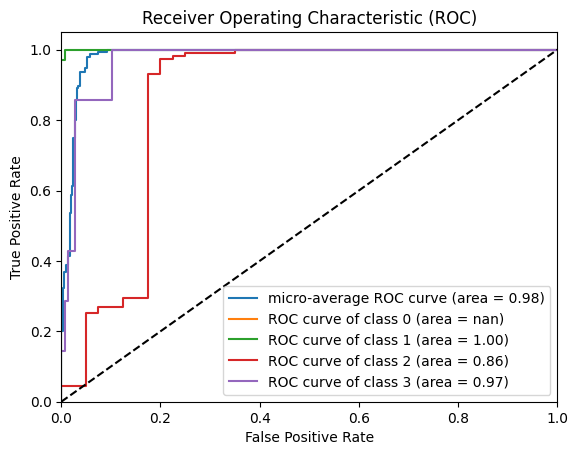

,Combination of Neurons,Epochs,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU Time,MSE,Precision,Recall,F1 Score
0,"(8, 5, 9, 15)",28,0.941667,0.948387,0.935065,6.443843,0.051613,0.905655,0.948387,0.926511


In [23]:

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training, validation, and testing sets
X_train, X_interim, y_train, y_interim = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42)

# One-hot encode the target variables
y_train = to_categorical(y_train)
y_validation = to_categorical(y_validation)
y_test = to_categorical(y_test)

# Print shapes of the datasets
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Define the combination of neurons and epochs
combination = {'neurons': (8, 5, 9, 15), 'epochs': 28}

results = []

start_time = time.time()

# Determine the number of unique classes
num_classes = y_train.shape[1]  # Assuming y_train is one-hot encoded

# Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
model = Sequential()
model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
model.add(PReLU())
model.add(Dense(combination['neurons'][1]))
model.add(PReLU())
model.add(Dense(combination['neurons'][2]))
model.add(PReLU())
model.add(Dense(combination['neurons'][3]))
model.add(PReLU())
model.add(Dense(num_classes, activation='sigmoid'))  # Sigmoid activation for binary classification
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Use categorical_crossentropy for one-hot encoded targets

# Print model summary
model.summary()

# Train the model
model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

# Calculate metrics
train_preds = model.predict(X_train).argmax(axis=1)
test_preds = model.predict(X_test).argmax(axis=1)
val_preds = model.predict(X_validation).argmax(axis=1)

# Convert one-hot encoded y_train back to single labels for metric calculation
y_train_labels = y_train.argmax(axis=1)
y_test_labels = y_test.argmax(axis=1)
y_val_labels = y_validation.argmax(axis=1)

accuracy_train = accuracy_score(y_train_labels, train_preds) # Use single label version of y_train
accuracy_test = accuracy_score(y_test_labels, test_preds)
accuracy_validation = accuracy_score(y_val_labels, val_preds)

mse = mean_squared_error(y_test_labels, test_preds)
precision = precision_score(y_test_labels, test_preds, average='weighted')
recall = recall_score(y_test_labels, test_preds, average='weighted')
f1 = f1_score(y_test_labels, test_preds, average='weighted')

results.append({
    'Combination of Neurons': combination['neurons'],
    'Epochs': combination['epochs'],
    'Training Accuracy': accuracy_train,
    'Testing Accuracy': accuracy_test,
    'Validation Accuracy': accuracy_validation,
    'CPU Time': time.time() - start_time,
    'MSE': mse,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

results_df = pd.DataFrame(results)
#print(results_df)

# Confusion Matrix
cm = confusion_matrix(y_test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC
y_test_prob = model.predict(X_test)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_test_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                 ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


results_df

In [24]:
num_classes

4

In [25]:
Y

,Add_lebel
0,2
1,2
2,1
3,2
4,1
...,...
1024,2
1025,2
1026,2
1027,1


Shapes:
X_train: (720, 10) y_train: (720, 3)
X_validation: (154, 10) y_validation: (154, 3)
X_test: (155, 10) y_test: (155, 3)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_185 (Dense)                    │ (None, 6)                   │              66 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_52 (PReLU)                   │ (None, 6)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_186 (Dense)                    │ (None, 5)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_53 (PReLU)                   │ (None, 5)                   │               5 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_187 (Dense)                    │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_54 (PReLU)                   │ (None, 12)                  │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_188 (Dense)                    │ (None, 13)                  │             169 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_55 (PReLU)                   │ (None, 13)                  │              13 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_189 (Dense)                    │ (None, 3)                   │              42 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 420 (1.64 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_240 (Dense)                    │ (None, 9)                   │              99 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_96 (PReLU)                   │ (None, 9)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_241 (Dense)                    │ (None, 6)                   │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_97 (PReLU)                   │ (None, 6)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_242 (Dense)                    │ (None, 10)                  │              70 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_98 (PReLU)                   │ (None, 10)                  │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_243 (Dense)                    │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_99 (PReLU)                   │ (None, 10)                  │              10 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_244 (Dense)                    │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407 (1.59 KB)

 Trainable params: 407 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


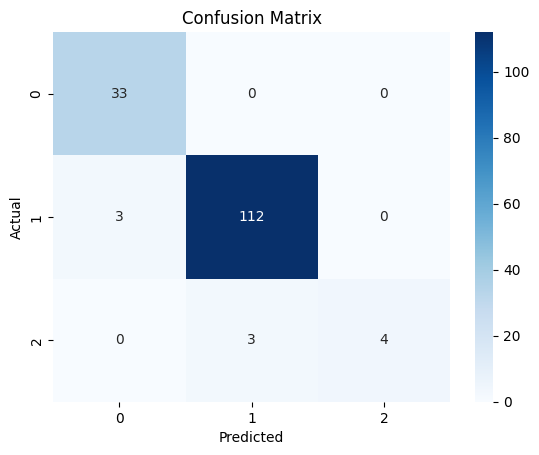

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


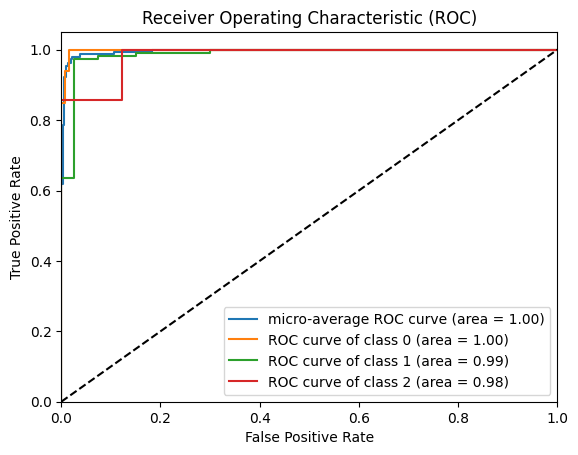

,Combination of Neurons,Epochs,Training Accuracy,Testing Accuracy,Validation Accuracy,CPU Time,MSE,Precision,Recall,F1 Score
0,"(6, 5, 12, 13)",68,0.995833,0.987097,0.954545,12.664209,0.012903,0.987317,0.987097,0.986077
1,"(12, 13, 15, 12)",66,1.000000,0.967742,0.974026,13.347143,0.032258,0.967819,0.967742,0.967720
2,"(5, 14, 14, 5)",31,0.940278,0.922581,0.922078,7.810173,0.077419,0.882436,0.922581,0.901470
3,"(8, 12, 14, 13)",66,0.998611,0.987097,0.961039,11.077761,0.012903,0.987287,0.987097,0.986897
4,"(12, 13, 11, 10)",34,0.994444,0.980645,0.967532,7.776765,0.019355,0.980778,0.980645,0.980651
5,"(15, 10, 9, 7)",47,0.987500,0.980645,0.967532,9.275789,0.019355,0.981137,0.980645,0.979645
6,"(10, 14, 8, 13)",69,0.997222,0.974194,0.974026,13.986812,0.025806,0.978380,0.974194,0.975693
7,"(7, 5, 5, 14)",43,0.994444,0.993548,0.980519,7.928356,0.006452,0.994355,0.993548,0.993749
8,"(10, 12, 7, 14)",49,0.998611,0.980645,0.974026,10.568367,0.019355,0.980778,0.980645,0.980651
9,"(8, 5, 9, 15)",28,0.959722,0.935484,0.954545,7.143613,0.064516,0.934433,0.935484,0.931938


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, mean_squared_error, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, PReLU
import seaborn as sns
import time

# Assume 'X' and 'Y' are defined
# Convert labels to start from 0
Y = Y - 1

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training, validation, and testing sets
X_train, X_interim, y_train, y_interim = train_test_split(X, Y, test_size=0.3, random_state=42)
X_validation, X_test, y_validation, y_test = train_test_split(X_interim, y_interim, test_size=0.5, random_state=42)

# Determine the number of unique classes
num_classes = Y.nunique() # Calculate number of unique classes from original Y

# One-hot encode the target variables
y_train = to_categorical(y_train, num_classes=num_classes) # Use calculated num_classes
y_validation = to_categorical(y_validation, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Print shapes of the datasets
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

# Define the combinations of neurons and epochs
combinations = [
    {'neurons': (6, 5, 12, 13), 'epochs': 68},
    {'neurons': (12, 13, 15, 12), 'epochs': 66},
    {'neurons': (5, 14, 14, 5), 'epochs': 31},
    {'neurons': (8, 12, 14, 13), 'epochs': 66},
    {'neurons': (12, 13, 11, 10), 'epochs': 34},
    {'neurons': (15, 10, 9, 7), 'epochs': 47},
    {'neurons': (10, 14, 8, 13), 'epochs': 69},
    {'neurons': (7, 5, 5, 14), 'epochs': 43},
    {'neurons': (10, 12, 7, 14), 'epochs': 49},
    {'neurons': (8, 5, 9, 15), 'epochs': 28},
    {'neurons': (13, 8, 7, 12), 'epochs': 7},
    {'neurons': (9, 6, 10, 10), 'epochs': 30},
]

results = []

for combination in combinations:
    start_time = time.time()

    # Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
    model = Sequential()
    model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][1]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][2]))
    model.add(PReLU())
    model.add(Dense(combination['neurons'][3]))
    model.add(PReLU())
    model.add(Dense(num_classes, activation='softmax'))  # Softmax activation for multiclass classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Use categorical_crossentropy for one-hot encoded targets

    # Print model summary
    model.summary()

    # Train the model
    model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

    # Calculate metrics
    train_preds = model.predict(X_train).argmax(axis=1)
    test_preds = model.predict(X_test).argmax(axis=1)
    val_preds = model.predict(X_validation).argmax(axis=1)

    # Convert one-hot encoded y_train back to single labels for metric calculation
    y_train_labels = y_train.argmax(axis=1)
    y_test_labels = y_test.argmax(axis=1)
    y_val_labels = y_validation.argmax(axis=1)

    accuracy_train = accuracy_score(y_train_labels, train_preds)  # Use single label version of y_train
    accuracy_test = accuracy_score(y_test_labels, test_preds)
    accuracy_validation = accuracy_score(y_val_labels, val_preds)

    mse = mean_squared_error(y_test_labels, test_preds)
    precision = precision_score(y_test_labels, test_preds, average='weighted')
    recall = recall_score(y_test_labels, test_preds, average='weighted')
    f1 = f1_score(y_test_labels, test_preds, average='weighted')

    results.append({
        'Combination of Neurons': combination['neurons'],
        'Epochs': combination['epochs'],
        'Training Accuracy': accuracy_train,
        'Testing Accuracy': accuracy_test,
        'Validation Accuracy': accuracy_validation,
        'CPU Time': time.time() - start_time,
        'MSE': mse,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

results_df = pd.DataFrame(results)
#print(results_df)

# Confusion Matrix
cm = confusion_matrix(y_test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve and AUC
y_test_prob = model.predict(X_test)
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_test_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                 ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


results_df

#Logistic Regression

## Cross validation with best combinations ofneurons

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, mean_squared_error, precision_score, recall_score, f1_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, PReLU
import seaborn as sns
import time

# Assume 'X' and 'Y' are defined
# Convert labels to start from 0
Y = Y - 1

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Determine the number of unique classes
num_classes = Y.nunique() # Calculate number of unique classes from original Y

# Define the combinations of neurons and epochs
combinations = [
    {'neurons': (6, 5, 12, 13), 'epochs': 68},
    {'neurons': (8, 12, 14, 13), 'epochs': 66},
]

# Define the number of folds for cross-validation
folds = [5, 10, 15]

results = []

for combination in combinations:
    for k in folds:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_mse = []
        fold_accuracy = []

        for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = Y[train_index], Y[test_index]

            # One-hot encode the target variables
            y_train = to_categorical(y_train, num_classes=num_classes)
            y_test = to_categorical(y_test, num_classes=num_classes)

            # Create and train MLP with ReLU activation for hidden layers and softmax activation for output layer
            model = Sequential()
            model.add(Dense(combination['neurons'][0], input_dim=X_train.shape[1]))
            model.add(PReLU())
            model.add(Dense(combination['neurons'][1]))
            model.add(PReLU())
            model.add(Dense(combination['neurons'][2]))
            model.add(PReLU())
            model.add(Dense(combination['neurons'][3]))
            model.add(PReLU())
            model.add(Dense(num_classes, activation='softmax'))  # Softmax activation for multiclass classification
            model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Use categorical_crossentropy for one-hot encoded targets

            # Train the model
            model.fit(X_train, y_train, epochs=combination['epochs'], verbose=0)

            # Calculate metrics
            test_preds = model.predict(X_test).argmax(axis=1)
            y_test_labels = y_test.argmax(axis=1)

            accuracy_test = accuracy_score(y_test_labels, test_preds)
            mse = mean_squared_error(y_test_labels, test_preds)

            fold_mse.append(mse)
            fold_accuracy.append(accuracy_test)

        avg_mse = np.mean(fold_mse)
        avg_accuracy = np.mean(fold_accuracy)

        results.append({
            'Combination of Neurons': combination['neurons'],
            'Epochs': combination['epochs'],
            'Folds': k,
            'Average MSE': avg_mse,
            'Average Accuracy': avg_accuracy,
        })

results_df = pd.DataFrame(results)
print(results_df)

# Get the best average MSE and accuracy
best_mse_result = results_df.loc[results_df['Average MSE'].idxmin()]
best_accuracy_result = results_df.loc[results_df['Average Accuracy'].idxmax()]

print("\nBest Average MSE Result:")
print(best_mse_result)

print("\nBest Average Accuracy Result:")
print(best_accuracy_result)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [28]:
# Save model to Google Drive
model_path = "/content/drive/MyDrive/Research/Mukhles and Biplob code/microcontroller_model.h5"
model.save(model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/Research/Mukhles and Biplob code/microcontroller_model.h5
